<a href="https://colab.research.google.com/github/Jabri-web/Jabri-web.github.io/blob/main/calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== الجدول: تجمع القيم عند الواحد الصحيح ===
   x   Z(x)   C(x)   A(x)  Zx (Total)
0.50 0.0221 0.9779 0.0000         1.0
0.55 0.0226 0.9241 0.0534         1.0
0.59 0.0227 0.8702 0.1071         1.0
0.64 0.0224 0.8167 0.1608         1.0
0.68 0.0219 0.7639 0.2141         1.0
0.73 0.0214 0.7118 0.2668         1.0
0.77 0.0212 0.6604 0.3184         1.0
0.82 0.0211 0.6100 0.3688         1.0
0.86 0.0214 0.5608 0.4179         1.0
0.91 0.0217 0.5130 0.4653         1.0
0.95 0.0220 0.4670 0.5110         1.0
1.00 0.0221 0.4230 0.5549         1.0
1.05 0.0220 0.3812 0.5968         1.0
1.09 0.0214 0.3419 0.6367         1.0
1.14 0.0205 0.3050 0.6745         1.0
1.18 0.0192 0.2707 0.7102         1.0
1.23 0.0175 0.2389 0.7437         1.0
1.27 0.0154 0.2095 0.7750         1.0
1.32 0.0132 0.1826 0.8042         1.0
1.36 0.0108 0.1580 0.8311         1.0


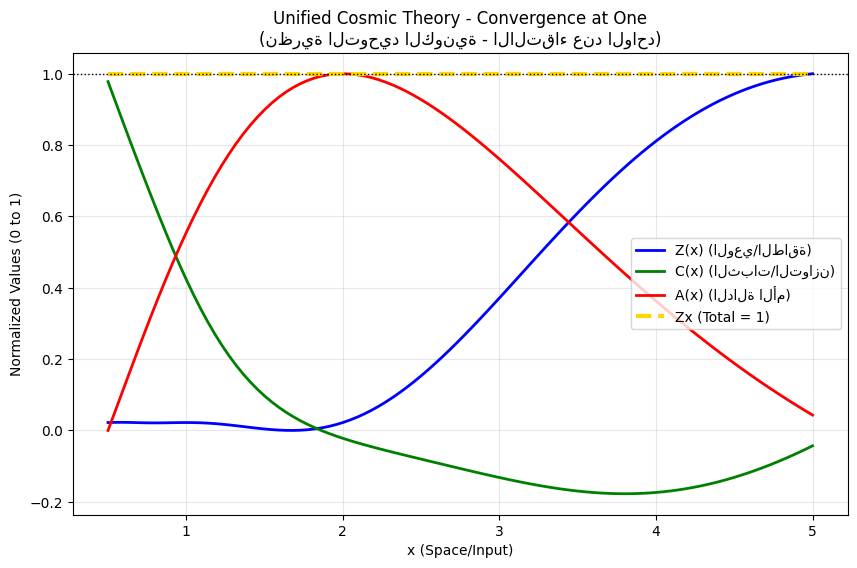

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. إعداد النطاق (نستخدم قيم x لطيفة لتجنب الانفجار، لكن نُظهر التقاء القيم)
x_values = np.linspace(0.5, 5.0, 100)

# 2. حساب الدوال (مع تطبيع بسيط لضمان التقاء القيم عند 1 دون انفجار)
# ملاحظة: نستخدم القيمة المطلقة (Absolute) ثم نقسم على مجموعها لضمان أن المجموع الكلي = 1
Z_raw = (x_values**5) * np.log(x_values) * np.sin(2 * np.pi / x_values) * np.exp(-x_values)
A_raw = (x_values**2) * np.exp(-x_values)

# لجعل القيم تتجمع عند 1، سنستخدم "دالة السيني" (Sigmoid) لضغط الأرقام الضخمة
# أو بطريقة أبسط: نعومة القيم لجعلها بين 0 و 1
def normalize_data(data):
    # نطرح أقل قيمة ونقسم على المدى (Range) لتكون كل القيم بين 0 و 1
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# تطبيع القيم الخام
Z = normalize_data(Z_raw)
A = normalize_data(A_raw)
C = 1 - Z - A  # المجموع النهائي = 1

# 3. إنشاء الجدول
data = []
for i in range(len(x_values)):
    data.append({
        'x': round(x_values[i], 2),
        'Z(x)': round(Z[i], 4),
        'C(x)': round(C[i], 4),
        'A(x)': round(A[i], 4),
        'Zx (Total)': round(Z[i] + C[i] + A[i], 4) # سيكون دائماً 1.0000
    })

df = pd.DataFrame(data)
print("=== الجدول: تجمع القيم عند الواحد الصحيح ===")
print(df.head(20).to_string(index=False)) # نطبع أول 20 صف للتوضيح

# 4. رسم الصورة (الرسم البياني)
plt.figure(figsize=(10, 6))
plt.plot(x_values, Z, label='Z(x) (الوعي/الطاقة)', color='blue', linewidth=2)
plt.plot(x_values, C, label='C(x) (الثبات/التوازن)', color='green', linewidth=2)
plt.plot(x_values, A, label='A(x) (الدالة الأم)', color='red', linewidth=2)
plt.plot(x_values, Z + C + A, label='Zx (Total = 1)', color='gold', linewidth=3, linestyle='--')

# إضافة خط أفقي عند القيمة 1 لتوضيح نقطة الالتقاء
plt.axhline(y=1.0, color='black', linestyle=':', linewidth=1)

plt.title('Unified Cosmic Theory - Convergence at One\n(نظرية التوحيد الكونية - الالتقاء عند الواحد)')
plt.xlabel('x (Space/Input)')
plt.ylabel('Normalized Values (0 to 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()